<a href="https://colab.research.google.com/github/santhosh1982/Youtube-Pytorch-Tutorial/blob/main/Neural_Network_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
class Model(nn.Module):
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

In [10]:
torch.manual_seed(41)
model = Model(4,8,9,3)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
url = 'https://gist.github.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)
my_df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [16]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


/tmp/ipykernel_1667/2393514860.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


In [17]:
X = my_df.drop('variety',axis=1)
y = my_df['variety']

In [18]:
X = X.values
y = y.values

In [20]:
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [25]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [26]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [33]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.2636, -0.2734,  0.3005, -0.3308],
         [-0.2350,  0.2720, -0.3718,  0.2452],
         [ 0.3045,  0.1357,  0.0896,  0.1933],
         [ 0.3782,  0.0407, -0.3600,  0.4613],
         [ 0.3666, -0.0116, -0.2923, -0.1937],
         [-0.4415,  0.3314, -0.0434,  0.3445],
         [ 0.1883, -0.0992, -0.3197,  0.1740],
         [-0.3208, -0.1111,  0.2972, -0.2723]], requires_grad=True),
 Parameter containing:
 tensor([-0.0245, -0.0679,  0.0573,  0.4814,  0.2923, -0.1877,  0.4425, -0.1626],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.1456,  0.1463, -0.0107, -0.3290,  0.3324, -0.0817,  0.2408, -0.2121],
         [-0.0361,  0.3031, -0.3068,  0.0136, -0.0046, -0.3022, -0.0685, -0.3241],
         [ 0.0764,  0.0595,  0.2023,  0.0088, -0.1424, -0.1275, -0.1320,  0.2750],
         [ 0.1133, -0.3520,  0.0632, -0.0472,  0.2579, -0.1034,  0.3086,  0.1093],
         [-0.3185,  0.0744, -0.0807,  0.1770, -0.3035, -0.0259,  0.2337,  0.1253],
       

In [38]:
epochs = 100
losses = []

for i in range(epochs):
    y_pred = model.forward(X_train)
    loss = criterion(y_pred,y_train)

    losses.append(loss.detach().numpy())

    if i%10 == 0:
      print(f'Epochs: {i} and loss: {loss}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epochs: 0 and loss: 0.009444158524274826
Epochs: 10 and loss: 0.008842410519719124
Epochs: 20 and loss: 0.008364548906683922
Epochs: 30 and loss: 0.007947775535285473
Epochs: 40 and loss: 0.0075550260953605175
Epochs: 50 and loss: 0.008337972685694695
Epochs: 60 and loss: 0.007017045747488737
Epochs: 70 and loss: 0.0066523863933980465
Epochs: 80 and loss: 0.006380168255418539
Epochs: 90 and loss: 0.00607693288475275


<Figure size 640x480 with 0 Axes>

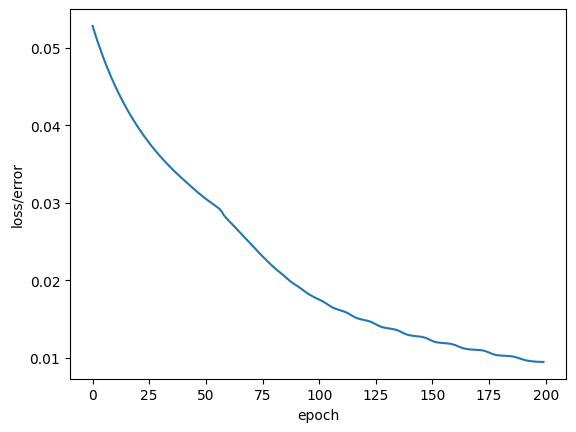

<Figure size 640x480 with 0 Axes>

In [37]:
plt.plot(range(epochs), losses)
plt.ylabel('loss/error')
plt.xlabel('epoch')
plt.figure()